# Pydra for Pipeline Builders

Pydra is the execution engine underlying the AIS Pipelines framework. When you write a
pipeline specification, the `command_task` field references a Pydra *task* (or *workflow*)
that defines the processing to be applied to the data.

This workbook covers what you need to know to:

* Use pre-built tasks from existing packages (e.g. `pydra-tasks-fsl`, `pydra-tasks-mrtrix3`)
* Wrap a new command-line tool as a shell task
* Write a custom Python processing step
* Compose multiple tasks into a pipeline workflow

> **Note:** Execution details — workers, caching, HPC schedulers, Docker/Singularity
> containers — are handled automatically by the framework and are not covered here.

## Setup

The following snippet is required to run async code within a Jupyter notebook:

In [1]:
import nest_asyncio

nest_asyncio.apply()

Create some sample data to work with throughout this workbook:

In [5]:
import json
from pathlib import Path
from tempfile import mkdtemp
from fileformats.medimage import Nifti1

test_dir = Path(mkdtemp())

# A sample JSON file
metadata = {"subject": "sub-01", "session": "ses-01", "age": 32}
json_file = test_dir / "metadata.json"
json_file.write_text(json.dumps(metadata))

# A directory of sample NIfTI files
nifti_dir = test_dir / "nifti"
nifti_dir.mkdir()
nifti_files = [Nifti1.sample(nifti_dir, seed=i) for i in range(5)]

## 1. What is a task?

A Pydra *task* is similar to a function: it takes inputs, performs an operation, and
returns outputs. The key difference is that parameterisation and execution are **two
separate steps**:

```python
# 1. Import the task class
from pydra.tasks.some_package import SomeTool

# 2. Parameterise — set the inputs
task = SomeTool(input_file="/path/to/file.nii", threshold=0.5)

# 3. Execute
outputs = task()
print(outputs.out_file)
```

This separation allows tasks to be checked for type errors before running, linked
together into workflows, and handed off to the framework for containerised execution.

### Running a pre-built task

Pre-built tasks are available from packages under `pydra.tasks.*` (e.g.
`pydra.tasks.fsl`, `pydra.tasks.mrtrix3`, `pydra.tasks.freesurfer`). Here we use
`pydra.tasks.common.LoadJson` as a simple example:

In [3]:
from pydra.tasks.common import LoadJson

load = LoadJson(file=json_file)
outputs = load()

print(outputs.out)

{'subject': 'sub-01', 'session': 'ses-01', 'age': 32}


### Iterating over a set of inputs

To apply the same task to multiple inputs, use `split()`. Pydra will run the task once
per item, collecting the results into a list:

In [7]:
from pprint import pprint
from pydra.tasks.mrtrix3.v3_1 import MrGrid

mrgrid = MrGrid(operation="regrid", voxel=(1.0, 1.0, 1.0)).split(
    in_file=nifti_files
)

outputs = mrgrid()
pprint(outputs.out_file)

[ImageFormat('/Users/tclo7153/Library/Caches/pydra/1.0a9/run-cache/workflow-81bb6b87a7dda1868933ba244ab38dbd/out_file.mif'),
 ImageFormat('/Users/tclo7153/Library/Caches/pydra/1.0a9/run-cache/workflow-81bb6b87a7dda1868933ba244ab38dbd/out_file (1).mif'),
 ImageFormat('/Users/tclo7153/Library/Caches/pydra/1.0a9/run-cache/workflow-81bb6b87a7dda1868933ba244ab38dbd/out_file (2).mif'),
 ImageFormat('/Users/tclo7153/Library/Caches/pydra/1.0a9/run-cache/workflow-81bb6b87a7dda1868933ba244ab38dbd/out_file (3).mif'),
 ImageFormat('/Users/tclo7153/Library/Caches/pydra/1.0a9/run-cache/workflow-81bb6b87a7dda1868933ba244ab38dbd/out_file (4).mif')]


## 2. Shell tasks

Shell tasks wrap command-line tools. This is the most common task type in neuroimaging
pipelines — most tools (FSL, FreeSurfer, MRTrix3, ANTs, ...) are command-line programs.

### Command-line templates

The quickest way to define a shell task is a **command-line template** — a string that
mirrors the tool's usage. Input fields are written as `<field_name>` and output fields
as `<out|field_name>`:

In [8]:
from pydra.compose import shell

Cp = shell.define("cp <in_file> <out|destination>")

cp = Cp(in_file=json_file, destination=test_dir / "copy.json")

# Inspect the command line that will be run before executing
print(cp.cmdline)

outputs = cp()
print(f"Copied to: {outputs.destination}")

cp /var/folders/n3/djm_ljc91k5dh_xpk017mnrc0000gp/T/tmpjj7nyeqe/metadata.json /var/folders/n3/djm_ljc91k5dh_xpk017mnrc0000gp/T/tmpjj7nyeqe/copy.json
Copied to: /var/folders/n3/djm_ljc91k5dh_xpk017mnrc0000gp/T/tmpjj7nyeqe/copy.json


### Specifying field types

By default, fields accept any file-system object. More specific types can be given by
appending a MIME or MIME-like type string after `:`. This lets the framework validate
inputs and enforce format compatibility between pipeline steps:

In [9]:
from pydra.utils import print_help

# A toy skull-stripping task — requires a NIfTI input, produces a NIfTI mask
BrainExtract = shell.define(
    "bet <in_file:medimage/nifti1> <out|out_file:medimage/nifti1>"
)

print_help(BrainExtract)

-------------------------
Help for Shell task 'bet'
-------------------------

Inputs:
- executable: str | Sequence[str]; default = 'bet'
    the first part of the command, can be a string, e.g. 'ls', or a list, e.g.
    ['ls', '-l', 'dirname']
- in_file: medimage/nifti1
- out_file: Path | bool; default = True
    The path specified for the output file, if True, the default 'path
    template' will be used.
- append_args: list[str | generic/file]; default-factory = list()
    Additional free-form arguments to append to the end of the command.

Outputs:
- out_file: medimage/nifti1
- return_code: int
    The process' exit code.
- stdout: str
    The standard output stream produced by the command.
- stderr: str
    The standard error stream produced by the command.



### Flags and optional arguments

Command-line flags and options are specified directly in the template:

* A flag with no space between it and the field template is treated as a **boolean**: `-R<recursive>`
* A flag followed by a space and a field template is treated as an **option**: `--fractional-intensity <frac>`
* Optional fields are marked with `?`: `<frac?>` or `<frac:float?>`
* Fields that accept multiple values use `+` (one or more) or `*` (zero or more): `<in_files+>`

In [10]:
Bet = shell.define(
    "bet "
    "<in_file:medimage/nifti1> "
    "<out|out_file:medimage/nifti1> "
    "-f <frac:float?> "
    "-g <gradient:float?> "
    "-m<mask> "
    "-R<robust> "
)

print_help(Bet)

-------------------------
Help for Shell task 'bet'
-------------------------

Inputs:
- executable: str | Sequence[str]; default = 'bet'
    the first part of the command, can be a string, e.g. 'ls', or a list, e.g.
    ['ls', '-l', 'dirname']
- in_file: medimage/nifti1
- out_file: Path | bool; default = True
    The path specified for the output file, if True, the default 'path
    template' will be used.
- frac: float | None; default = None ('-f')
- gradient: float | None; default = None ('-g')
- mask: bool; default = False ('-m')
- robust: bool; default = False ('-R')
- append_args: list[str | generic/file]; default-factory = list()
    Additional free-form arguments to append to the end of the command.

Outputs:
- out_file: medimage/nifti1
- return_code: int
    The process' exit code.
- stdout: str
    The standard output stream produced by the command.
- stderr: str
    The standard error stream produced by the command.



In [11]:
bet = Bet(in_file=nifti_files[0], frac=0.4, robust=True)
print(bet.cmdline)

bet /var/folders/n3/djm_ljc91k5dh_xpk017mnrc0000gp/T/tmpjj7nyeqe/nifti/0UAqFzWsDK4FrUMp48Y3tT3Q.nii /Users/tclo7153/git/workflows/founding-gide-workshop/notebooks/out_file.nii -f 0.4 -R


### Default values

Default values are appended to the field template after `=`:

In [12]:
from pydra.utils import get_fields

BetWithDefaults = shell.define(
    "bet "
    "<in_file:medimage/nifti1> "
    "<out|out_file:medimage/nifti1> "
    "-f <frac:float=0.5> "
    "-m<mask=False> "
)

print(f"Default frac: {get_fields(BetWithDefaults).frac.default}")

# The default is used when the field is not provided
bet = BetWithDefaults(in_file=nifti_files[0])
print(bet.cmdline)

Default frac: 0.5
bet /var/folders/n3/djm_ljc91k5dh_xpk017mnrc0000gp/T/tmpjj7nyeqe/nifti/0UAqFzWsDK4FrUMp48Y3tT3Q.nii /Users/tclo7153/git/workflows/founding-gide-workshop/notebooks/out_file.nii -f 0.5


### Output path templates

When an output file path is not specified by the user, Pydra generates one from the
field name and its type extension. You can control this with the `$` operator:

In [13]:
from fileformats.generic import File

# The output will be named "brain.nii" by default (from the $brain template)
BetTemplated = shell.define(
    "bet <in_file:medimage/nifti1> <out|brain:medimage/nifti1$brain.nii>"
)

bet = BetTemplated(in_file=nifti_files[0])
print(f"Default output path: {bet.cmdline}")

# The default can always be overridden at parameterisation
bet_custom = BetTemplated(in_file=nifti_files[0], brain=test_dir / "my_brain.nii")
print(f"Custom output path:  {bet_custom.cmdline}")

Default output path: bet /var/folders/n3/djm_ljc91k5dh_xpk017mnrc0000gp/T/tmpjj7nyeqe/nifti/0UAqFzWsDK4FrUMp48Y3tT3Q.nii /Users/tclo7153/git/workflows/founding-gide-workshop/notebooks/brain.nii
Custom output path:  bet /var/folders/n3/djm_ljc91k5dh_xpk017mnrc0000gp/T/tmpjj7nyeqe/nifti/0UAqFzWsDK4FrUMp48Y3tT3Q.nii /var/folders/n3/djm_ljc91k5dh_xpk017mnrc0000gp/T/tmpjj7nyeqe/my_brain.nii


### Callable outputs

Some tool outputs are not specified on the command line but can be derived from the
tool's output directory or stdout/stderr. A Python callable can be used for these:

In [14]:
import os


def get_file_size(out_file: Path) -> int:
    """Return the size of the output file in bytes."""
    return os.stat(out_file).st_size


CpWithSize = shell.define(
    "cp <in_file:file> <out|out_file:file>",
    outputs={"out_file_size": get_file_size},
)

cp = CpWithSize(in_file=File.sample())
outputs = cp()

print(f"Output file: {outputs.out_file}")
print(f"File size:   {outputs.out_file_size} bytes")

Output file: /Users/tclo7153/Library/Caches/pydra/1.0a9/run-cache/shell-974af270a8f8ad3ecf3606af4ae2ee81/out_file
File size:   256 bytes


The callable can accept any combination of the following keyword arguments, which Pydra
will supply automatically:

| Argument | Description |
|---|---|
| `cache_dir` | `Path` to the working directory the command ran in |
| `inputs` | dict of all resolved task inputs |
| `stdout` | standard output from the command |
| `stderr` | standard error from the command |
| *input name* | any input field by name (e.g. `in_file`, `out_file`) |

## 3. Python tasks

Python tasks wrap Python functions. Use the `@python.define` decorator on a function
to turn it into a parameterisable task:

In [15]:
from pydra.compose import python


@python.define
def Scale(value: float, factor: float) -> float:
    """Multiply a value by a scale factor."""
    return value * factor


scale = Scale(value=3.14, factor=2.0)
outputs = scale()

print(outputs.out)

6.28


### Type annotations

Type annotations are checked at parameterisation time. An incorrect type raises a
`TypeError` before the task runs:

In [16]:
try:
    Scale(value="not-a-float", factor=2.0)
except TypeError as e:
    print(f"TypeError: {e}")

TypeError: Incorrect type for field in 'value' field of Scale interface : 'not-a-float' is not of type <class 'float'> (and cannot be coerced to it)


### Named outputs

When a function returns multiple values, name them with the `outputs` argument. Pydra
also parses Google/NumPy/reST docstrings to extract help text automatically:

In [17]:
from pydra.utils import print_help


@python.define(outputs=["mean", "std"])
def DescribeDistribution(values: list[float]) -> tuple[float, float]:
    """Compute the mean and standard deviation of a list of values.

    Args:
        values: Input values

    Returns:
        mean: Mean of the values
        std: Standard deviation of the values
    """
    import statistics

    return statistics.mean(values), statistics.stdev(values)


print_help(DescribeDistribution)

result = DescribeDistribution(values=[2.0, 4.0, 4.0, 4.0, 5.0, 5.0, 7.0, 9.0])()
print(f"Mean: {result.mean:.2f}, Std: {result.std:.2f}")

-------------------------------------------
Help for Python task 'DescribeDistribution'
-------------------------------------------

Inputs:
- values: list[float]
    Input values
- function: Callable[]; default = DescribeDistribution()

Outputs:
- mean: float
    Mean of the values
- std: float
    Standard deviation of the values

Mean: 5.00, Std: 2.14


### Wrapping an existing function

`python.define` can also be called directly on a function defined elsewhere to wrap it
as a task without modifying the original:

In [18]:
import numpy as np

NumpyCorrelate = python.define(np.correlate, outputs=["correlation"])

outputs = NumpyCorrelate(a=[1, 2, 3], v=[0, 1, 0.5])()
print(outputs.correlation)

[3.5]


## 4. Workflows

A workflow is a directed acyclic graph (DAG) of tasks. It is defined using
`@workflow.define` on a *constructor function* that describes how tasks connect.
Nodes are added with `workflow.add()`, which returns an outputs placeholder that
can be wired into downstream task inputs.

### Connecting tasks

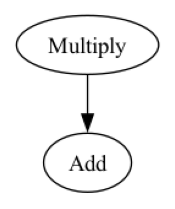

Result: 7.0


In [19]:
from pydra.compose import workflow
from pydra.utils import show_workflow


@python.define
def Add(a: float, b: float) -> float:
    return a + b


@python.define
def Multiply(a: float, b: float) -> float:
    return a * b


@workflow.define
def ScaleAndShift(x: float, scale: float, shift: float) -> float:
    """Multiply x by scale, then add shift."""
    scaled = workflow.add(Multiply(a=x, b=scale))
    shifted = workflow.add(Add(a=scaled.out, b=shift))  # output of scaled feeds in here
    return shifted.out


show_workflow(ScaleAndShift, figsize=(2, 3))

outputs = ScaleAndShift(x=3.0, scale=2.0, shift=1.0)()
print(f"Result: {outputs.out}")  # (3 * 2) + 1 = 7

### Splitting and combining within a workflow

`split()` and `combine()` can be used on nodes within a workflow, allowing a single
workflow to fan out across a set of inputs and collect the results:

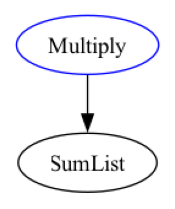

Result: 100.0


In [20]:
@python.define
def SumList(values: list[float]) -> float:
    return sum(values)


@workflow.define
def ScaleAndSum(inputs: list[float], scale: float) -> float:
    """Scale each value independently, then sum the results."""
    # Split Multiply across all inputs, combine the results back into a list
    scaled = workflow.add(Multiply(b=scale).split(a=inputs).combine("Multiply.a"))
    total = workflow.add(SumList(values=scaled.out))
    return total.out


show_workflow(ScaleAndSum, figsize=(2, 3))

outputs = ScaleAndSum(inputs=[1.0, 2.0, 3.0, 4.0], scale=10.0)()
print(f"Result: {outputs.out}")  # (1+2+3+4) * 10 = 100

### Conditional logic

Regular Python `if`/`else` can be used inside the constructor function to conditionally
include or omit nodes based on the workflow's *inputs* (not the outputs of upstream
tasks, which are only known at runtime):

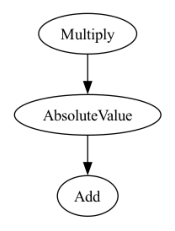

In [21]:
@python.define
def AbsoluteValue(x: float) -> float:
    return abs(x)


@workflow.define
def ScaleAndShiftConditional(
    x: float,
    scale: float,
    shift: float,
    use_abs: bool = False,
) -> float:
    scaled = workflow.add(Multiply(a=x, b=scale))

    if use_abs:
        rectified = workflow.add(AbsoluteValue(x=scaled.out))
        shift_input = rectified.out
    else:
        shift_input = scaled.out

    shifted = workflow.add(Add(a=shift_input, b=shift))
    return shifted.out


# The graph shape depends on the input value of use_abs
show_workflow(ScaleAndShiftConditional(use_abs=True), figsize=(2, 3.5))

### Mixing shell and Python tasks

Shell and Python tasks can be freely mixed in a workflow. Here is a simple preprocessing
pipeline that regrids a set of NIfTI files then summarises the voxel statistics:

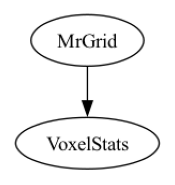

Resampled: /private/var/folders/n3/djm_ljc91k5dh_xpk017mnrc0000gp/T/tmpjj7nyeqe/cache/workflow-56c4f109b2dd5791eba00b30ad5d2bfc/out.nii
Mean: 32029.3075, Std: 15755.9463


In [26]:
from pydra.tasks.mrtrix3.v3_1 import MrGrid


@python.define(outputs=["mean", "std"])
def VoxelStats(nifti: Nifti1) -> tuple[float, float]:
    """Return mean and std of voxel intensities in a NIfTI file."""
    import nibabel as nib
    import numpy as np

    data = nib.load(nifti.fspath).get_fdata()
    return float(np.mean(data)), float(np.std(data))


@workflow.define(outputs=["resampled", "mean", "std"])
def ResampleAndStats(
    in_file: Nifti1,
    target_voxel: tuple[float, float, float] = (1.0, 1.0, 1.0),
) -> tuple[Nifti1, float, float]:
    regrid = workflow.add(
        MrGrid(in_file=in_file, operation="regrid", out_file="out.nii", voxel=target_voxel)
    )
    stats = workflow.add(VoxelStats(nifti=regrid.out_file))
    return regrid.out_file, stats.mean, stats.std


show_workflow(ResampleAndStats, figsize=(2, 3))

outputs = ResampleAndStats(in_file=nifti_files[0])(cache_root=test_dir / "cache")
print(f"Resampled: {outputs.resampled}")
print(f"Mean: {outputs.mean:.4f}, Std: {outputs.std:.4f}")